In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


In [3]:
data= pd.read_csv(r"C:\Users\PRATHEEK POOJARY\OneDrive\Desktop\Machine Learning\datasets\titanic.csv")
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [5]:
data['Age']= data['Age'].fillna(data['Age'].mean())
data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [6]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()
data['Sex_e']=encoder.fit_transform(data['Sex'])
data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Sex_e
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,NaN,S,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C85,C,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,NaN,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,C123,S,0
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,NaN,S,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.000000,0,0,211536,13.0000,NaN,S,1
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.000000,0,0,112053,30.0000,B42,S,0
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,29.699118,1,2,W./C. 6607,23.4500,NaN,S,0
889,890,1,1,"Behr, Mr. Karl Howell",male,26.000000,0,0,111369,30.0000,C148,C,1


In [7]:
x=data[['Sex_e','Pclass','Age','Fare']]
y=data['Survived']
x

,Sex_e,Pclass,Age,Fare
0,1,3,22.000000,7.2500
1,0,1,38.000000,71.2833
2,0,3,26.000000,7.9250
3,0,1,35.000000,53.1000
4,1,3,35.000000,8.0500
...,...,...,...,...
886,1,2,27.000000,13.0000
887,0,1,19.000000,30.0000
888,0,3,29.699118,23.4500
889,1,1,26.000000,30.0000


In [8]:
x.describe()

,Sex_e,Pclass,Age,Fare
count,891.000000,891.000000,891.000000,891.000000
mean,0.647587,2.308642,29.699118,32.204208
std,0.477990,0.836071,13.002015,49.693429
min,0.000000,1.000000,0.420000,0.000000
25%,0.000000,2.000000,22.000000,7.910400
50%,1.000000,3.000000,29.699118,14.454200
75%,1.000000,3.000000,35.000000,31.000000
max,1.000000,3.000000,80.000000,512.329200


In [9]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test= train_test_split(x, y, test_size=0.30,random_state=40)

DECISION TREE

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
decision= DecisionTreeClassifier()
decision.fit(x_train,y_train)

DecisionTreeClassifier()

In [11]:
y_deci= decision.predict(x_test)
accuracy_score(y_test,y_deci)

0.7798507462686567

Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier
random= RandomForestClassifier(n_estimators=100)
random.fit(x_train,y_train)


RandomForestClassifier()

In [26]:
y_rand=random.predict(x_test)
accuracy_score(y_test,y_rand)

0.832089552238806

BAGGING CLASSIFIER

In [42]:
from sklearn.ensemble import BaggingClassifier
bagg=BaggingClassifier(estimator=RandomForestClassifier(), n_estimators=100)
bagg.fit(x_train,y_train)

BaggingClassifier(estimator=RandomForestClassifier(), n_estimators=100)

In [56]:
y_bagg= bagg.predict(x_test)
accuracy_score(y_test,y_bagg)

0.8470149253731343

ADA BOOSTING

In [57]:
from sklearn.ensemble import AdaBoostClassifier
ada=AdaBoostClassifier(estimator=RandomForestClassifier())
ada.fit(x_train,y_train)

AdaBoostClassifier(estimator=RandomForestClassifier())

In [58]:
y_ada=ada.predict(x_test)
accuracy_score(y_test,y_ada)

0.8171641791044776

GRADIENT BOOSTING

In [59]:
from sklearn.ensemble import GradientBoostingClassifier
gradient= GradientBoostingClassifier()
gradient.fit(x_train, y_train)

GradientBoostingClassifier()

In [60]:
y_grad=gradient.predict(x_test)
accuracy_score(y_test,y_grad)

0.8544776119402985

XGBOOSTING

In [61]:
from xgboost import XGBClassifier
import xgboost
xgbm=XGBClassifier()
xgbm.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [62]:
y_xgb= xgbm.predict(x_test)
accuracy_score(y_test,y_xgb)

0.8283582089552238

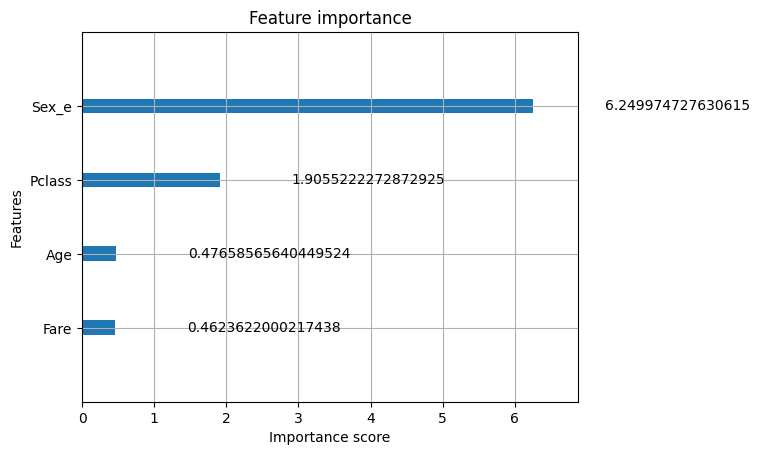

In [ ]:
import matplotlib.pyplot as plt
xgboost.plot_importance(xgbm, importance_type='gain',)  # or 'weight', 'cover'
plt.show()
